In [265]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

In [266]:
df = pd.read_csv('E:/Courses/DS/Dataset/Cardiovascular_Disease.csv')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [267]:
# convert age
age_data = df['age']//365
df['age'] = age_data

In [268]:
# height = 125 - 200
# weight = 40 - 120
# ap_hi = 100 - 200
# ap_low = 50 - 90

data_filter = df[(df['height'].between(125, 200)) & 
                 (df['weight'].between(40,120)) & 
                 (df['ap_hi'].between(100,200)) & 
                 (df['ap_lo'].between(50,90))]

data_filter.head()
df = data_filter

In [269]:
df.shape

(62070, 13)

## Extract Sample

In [270]:
df_sample = df.sample(n=5000)
df_sample.shape

(5000, 13)

## Feature and Target

In [271]:
df.columns

Index(['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='str')

In [272]:
features = ['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
            'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [273]:
x = df_sample[features]
y = df_sample[target]

## Train and Test

In [274]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state= 42, stratify=y
)

## Feature Scaling

In [275]:
scaler = StandardScaler()

In [276]:
x_train_scale = scaler.fit_transform(x_train)
x_test_scale = scaler.transform(x_test)

## Define Model

In [277]:
model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

In [278]:
model.fit(x_train_scale, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [279]:
y_pred = model.predict(x_test_scale)

## Metrics

In [280]:

cr = classification_report(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [281]:
print(cr)
print('\n\n')
print(cm)

              precision    recall  f1-score   support

           0       0.69      0.82      0.75       538
           1       0.73      0.56      0.64       462

    accuracy                           0.70      1000
   macro avg       0.71      0.69      0.69      1000
weighted avg       0.71      0.70      0.70      1000




[[442  96]
 [201 261]]


## Visualization

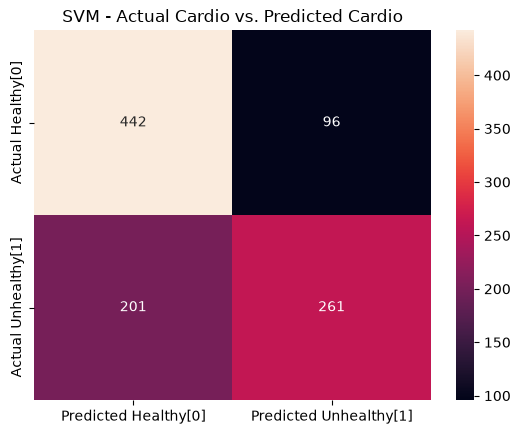

In [282]:
sns.heatmap(cm, annot = True, fmt = '1.0f', xticklabels=['Predicted Healthy[0]', 'Predicted Unhealthy[1]'],
            yticklabels=['Actual Healthy[0]', 'Actual Unhealthy[1]'])
plt.title('SVM - Actual Cardio vs. Predicted Cardio')
plt.show()

In [283]:
# height = 125 - 200
# weight = 40 - 120
# ap_hi = 100 - 200
# ap_low = 50 - 90

data = {
    'id' : [1, 2, 3],
    'age': [30,40,29], 
    'gender': [1,2,1], 
    'height': [130, 140, 124], 
    'weight': [50, 60, 55], 
    'ap_hi': [130, 140, 120], 
    'ap_lo': [90, 80, 70], 
    'cholesterol': [1,2,3], 
    'gluc': [3,2,1], 
    'smoke': [1,0,0], 
    'alco': [1,1,1], 
    'active': [0,1,0]
}

In [284]:
x_data = pd.DataFrame(data)
x_data_scale = scaler.transform(x_data)
x_pred = model.predict(x_data_scale)

In [285]:
x_data['svm_pred'] = x_pred

In [286]:
x_data

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,svm_pred
0,1,30,1,130,50,130,90,1,3,1,1,0,1
1,2,40,2,140,60,140,80,2,2,0,1,1,1
2,3,29,1,124,55,120,70,3,1,0,1,0,1
